In [171]:
# Install the tsfm library
! pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.22"

  Cloning https://github.com/ibm-granite/granite-tsfm.git (to revision v0.2.22) to /private/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/pip-install-uh8lfprm/granite-tsfm_78f49441a8024b2387294774da97af31
  Running command git clone --filter=blob:none --quiet https://github.com/ibm-granite/granite-tsfm.git /private/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/pip-install-uh8lfprm/granite-tsfm_78f49441a8024b2387294774da97af31
  Running command git checkout -q 216850d0cb073e31689049c1334f701fe11bc2c3
  Resolved https://github.com/ibm-granite/granite-tsfm.git to commit 216850d0cb073e31689049c1334f701fe11bc2c3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [172]:
import math
import os

import numpy as np
import pandas as pd
import torch
from torch.optim import AdamW
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, get_cosine_schedule_with_warmup
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_selection import mutual_info_regression

from tsfm_public import (
    TimeSeriesPreprocessor,
    TrackingCallback,
)
import tempfile
from tsfm_public.toolkit.lr_finder import optimal_lr_finder
from tsfm_public.toolkit.visualization import plot_predictions

In [173]:
# Reduced context length for slowly-changing variables like coolant temperature
# Original: 512 timesteps (after 5x downsampling = 2560 seconds = ~43 minutes)
# New: 256 timesteps (after 5x downsampling = 1280 seconds = ~21 minutes)
context_length = 512
forecast_length = 96

TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"
revision = "main"
OUT_DIR = "ttm-finetune"

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [174]:
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata" 
time_col = 'ENGINE_RUN_TINE ()'

df_list = []
for file in os.listdir(path):
  if file.endswith('.csv'):
    df = pd.read_csv(f'{path}/{file}', index_col=False)
    df['drive_id'] = file
    df_list.append(df)

print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


129 files loaded out of 129


In [175]:
def remove_zero_variance_columns(df: pd.DataFrame, exclude_cols: list[str] = None) -> pd.DataFrame:
  """
  Compute std of each std-computable column (numeric only)
  """
  if exclude_cols is None:
        exclude_cols = []
    
  numeric_cols = df.select_dtypes(include=[np.number]).columns
  cols_to_check = [col for col in numeric_cols if col not in exclude_cols]
  
  std_df = df[cols_to_check].std()
  zero_variance_cols = std_df[std_df == 0].index.tolist()
  
  print(f'{len(zero_variance_cols)} columns with zero variance: {zero_variance_cols}')
  
  if len(zero_variance_cols) > 0:
      df = df.drop(columns=zero_variance_cols)
  
  return df

In [176]:
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame, id_cols: list[str] = None) -> pd.DataFrame:
  """
  Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
  This preserves the overall statistics while removing duplicate entries.
  
  Note: The time column itself is not averaged (it becomes the group key).
  Only numeric columns are averaged when multiple rows share the same timestamp.
  """
  if id_cols is None:
        id_cols = []
    
  
  existing_id_cols = [col for col in id_cols if col in df.columns]
  
  group_cols = [time_col] + existing_id_cols
  
  agg_dict = {}
  for col in df.columns:
      if col not in group_cols:
          if pd.api.types.is_numeric_dtype(df[col]):
              agg_dict[col] = 'mean'
          else:
              agg_dict[col] = 'first'
  
  df_clean = df.groupby(group_cols, as_index=False).agg(agg_dict)
  
  return df_clean


In [177]:
def downsample(df, time_col, source_file_col, downsample_factor=2):
    result_dfs = []
    
    for source_file in df[source_file_col].unique():
        file_df = df[df[source_file_col] == source_file].copy()
        
        if len(file_df) < downsample_factor * 2:
            continue
        
        file_df = file_df.sort_values(time_col).reset_index(drop=True)
        
        # Simple decimation without pre-smoothing
        # The TTM model handles noise internally
        downsampled = file_df.iloc[::downsample_factor].copy()
        downsampled[time_col] = np.arange(len(downsampled)) * downsample_factor
        
        result_dfs.append(downsampled.reset_index(drop=True))
    
    return pd.concat(result_dfs, ignore_index=True)


In [178]:
def filter_long_drives(df, id_col='drive_id', min_length=608):
    """Keep only drives long enough for your context window"""
    drive_lengths = df.groupby(id_col).size()
    valid_drives = drive_lengths[drive_lengths >= min_length].index
    
    print(f"Keeping {len(valid_drives)}/{df[id_col].nunique()} drives")
    print(f"Dropped {len(df) - df[df[id_col].isin(valid_drives)].shape[0]} timesteps")
    
    return df[df[id_col].isin(valid_drives)].reset_index(drop=True)

In [179]:
data = pd.concat(df_list, ignore_index=True)

# Clean up

print(f"Total samples: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")

data = mean_fill_missing_timestamps_and_remove_duplicates(data, id_cols=["drive_id"])
data = remove_zero_variance_columns(data, exclude_cols=["drive_id"])
data = downsample(
    data,
    time_col='ENGINE_RUN_TINE ()',
    source_file_col='drive_id',
    downsample_factor=1
)

data = filter_long_drives(data)


data['speed_change'] = data.groupby('drive_id')['VEHICLE_SPEED ()'].diff()
data['rpm_change'] = data.groupby('drive_id')['ENGINE_RPM ()'].diff()


Total samples: 304,299
Unique drives: 129
3 columns with zero variance: ['FUEL_AIR_COMMANDED_EQUIV_RATIO ()', 'TIME_RUN_WITH_MIL_ON ()', 'DISTANCE_TRAVELED_WITH_MIL_ON ()']
Keeping 59/129 drives
Dropped 28269 timesteps


In [180]:
from tsfm_public import get_datasets

target_columns = [
    'COOLANT_TEMPERATURE ()',
    'ENGINE_RPM ()',
    'VEHICLE_SPEED ()',
    'THROTTLE ()',
    'ENGINE_LOAD ()',
    'INTAKE_MANIFOLD_PRESSURE ()',
]

split_params = {"train": 0.75, "test": 0.25}

column_specifiers = {
    "timestamp_column": time_col,
    "id_columns": ["drive_id"],
    "target_columns": target_columns,
    "conditional_columns": [col for col in data.columns if col not in target_columns + ["drive_id", time_col]],
}

tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=context_length,
    prediction_length=forecast_length,
    scaling=True,
    encode_categorical=False,
    scaler_type="standard",
    freq="s",
)

tsp = tsp.train(data)

train_dataset, valid_dataset, test_dataset = get_datasets(
    tsp,
    data,
    split_params,
    fewshot_fraction=1.0,
    fewshot_location="first",
    use_frequency_token=True,  # Enable frequency token for revision "180-60-ft-l1-r2.1"
)

def remove_zero_padded_samples(dataset):
    """Remove samples that are all zeros"""
    valid_indices = []
    for idx in range(len(dataset)):
        sample = dataset[idx]
        if 'past_values' in sample:
            if sample['past_values'].std() > 0.01:
                valid_indices.append(idx)
    
    print(f"Kept {len(valid_indices)}/{len(dataset)} valid samples")
    return torch.utils.data.Subset(dataset, valid_indices)

train_dataset = remove_zero_padded_samples(train_dataset)
valid_dataset = remove_zero_padded_samples(valid_dataset)
test_dataset = remove_zero_padded_samples(test_dataset)


Kept 7384/7384 valid samples
Kept 44/44 valid samples
Kept 6940/6955 valid samples


In [181]:
from tsfm_public import get_model

zeroshot_model = get_model(
    TTM_MODEL_PATH,
    context_length=context_length,
    prediction_length=forecast_length,
)


INFO:p-51643:t-8534990592:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-51643:t-8534990592:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = main.
INFO:p-51643:t-8534990592:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 96


In [184]:
temp_dir = tempfile.mkdtemp()
zeroshot_trainer = Trainer(
    model=zeroshot_model,
    args=TrainingArguments(
        output_dir=temp_dir,
        per_device_eval_batch_size=64,
    ),
)

In [185]:
zeroshot_trainer.evaluate(test_dataset)

{'eval_loss': 0.8157655596733093,
 'eval_model_preparation_time': 0.0024,
 'eval_runtime': 11.6206,
 'eval_samples_per_second': 597.214,
 'eval_steps_per_second': 9.38}

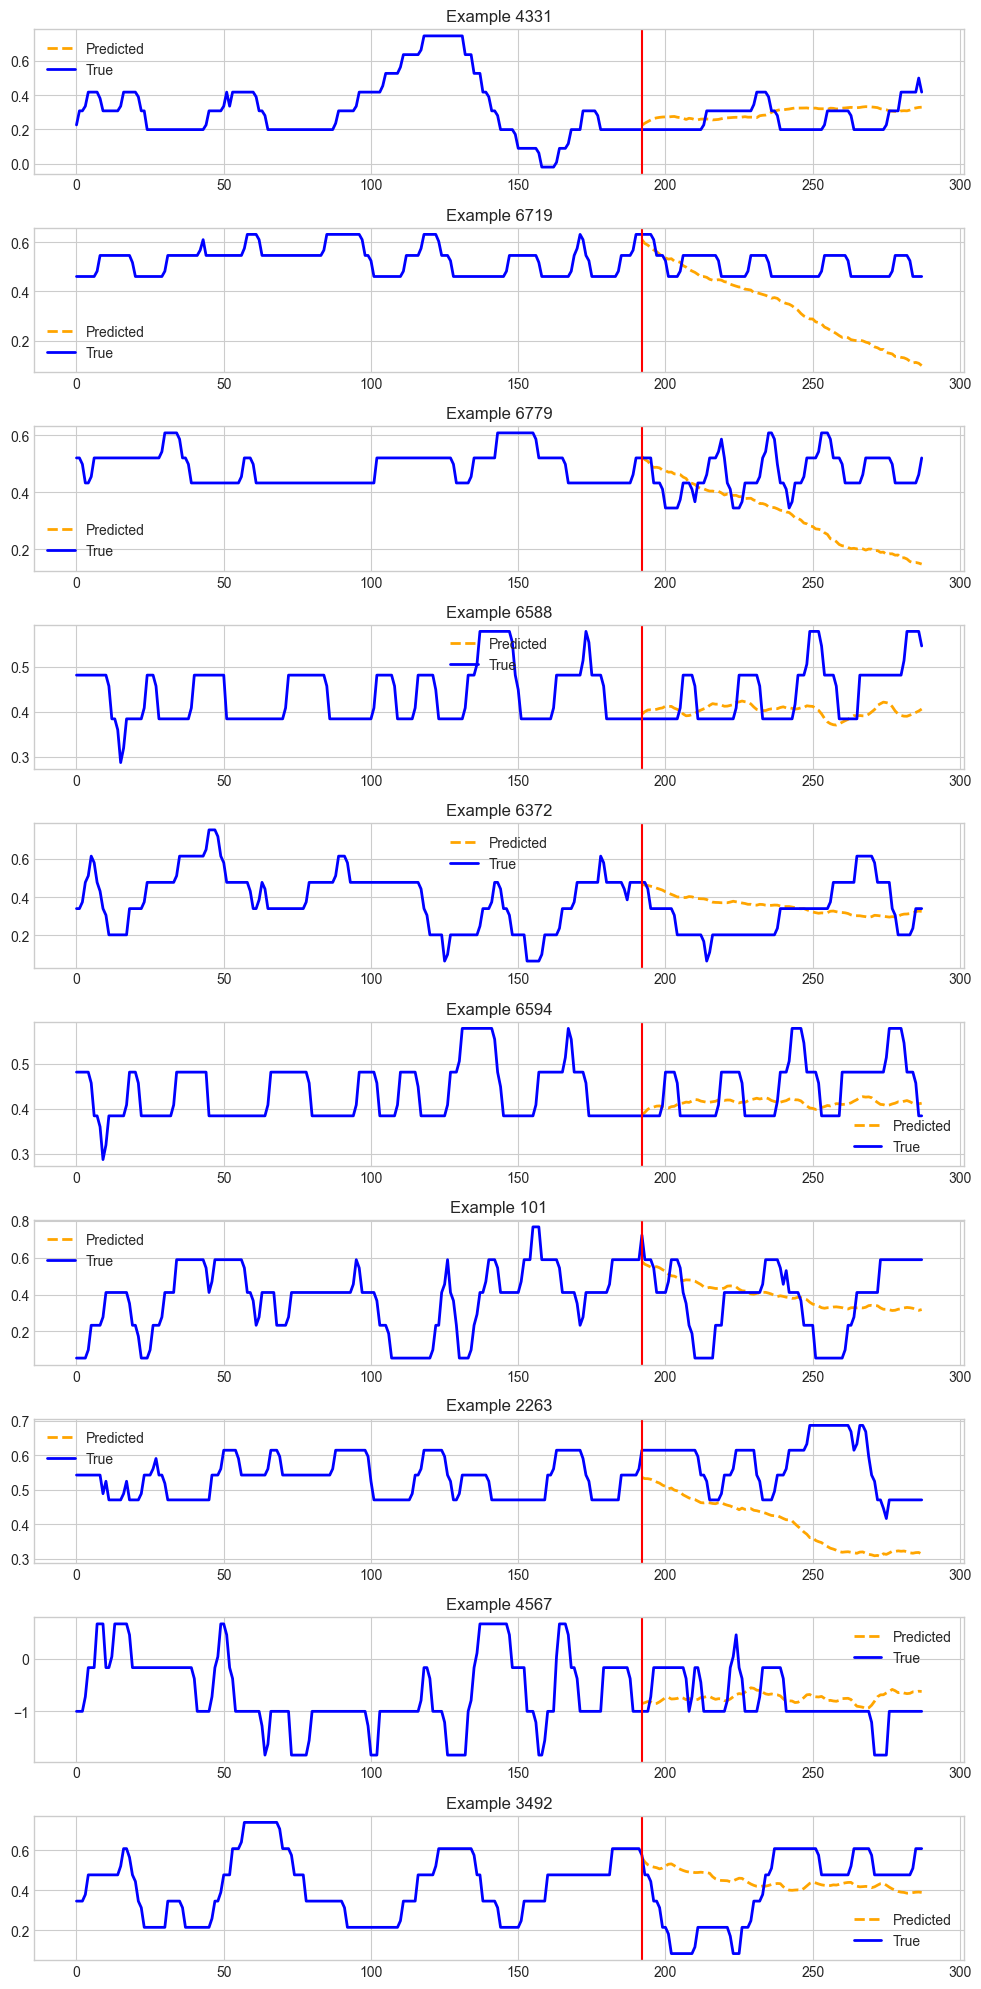

In [186]:
plot_predictions(
    model=zeroshot_trainer.model,
    dset=test_dataset,
    plot_prefix="test_zeroshot",
    channel=0,
)

In [187]:
finetune_forecast_model = get_model(
    TTM_MODEL_PATH,
    context_length=context_length,
    prediction_length=forecast_length,
)


INFO:p-51643:t-8534990592:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-51643:t-8534990592:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = main.
INFO:p-51643:t-8534990592:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 96


In [188]:
for param in finetune_forecast_model.backbone.parameters():
    param.requires_grad = False

In [189]:
num_epochs = 100
batch_size = 64

learning_rate, finetune_forecast_model = optimal_lr_finder(
    finetune_forecast_model,
    train_dataset,
    batch_size=batch_size,
    device=device,
    enable_prefix_tuning=False,
)
print("OPTIMAL SUGGESTED LEARNING RATE =", learning_rate)

INFO:p-51643:t-8534990592:lr_finder.py:optimal_lr_finder:LR Finder: Running learning rate (LR) finder algorithm. If the suggested LR is very low, we suggest setting the LR manually.
INFO:p-51643:t-8534990592:lr_finder.py:optimal_lr_finder:LR Finder: Using CPU.
INFO:p-51643:t-8534990592:lr_finder.py:optimal_lr_finder:LR Finder: Suggested learning rate = 0.00043287612810830566


OPTIMAL SUGGESTED LEARNING RATE = 0.00043287612810830566


In [193]:
import torch
import torch.nn.functional as F
from transformers import Trainer, TrainingArguments
from accelerate import notebook_launcher

# Loss functions (unchanged)
class MultiObjectiveLoss(torch.nn.Module):
    """
    Comprehensive loss combining:
    - MSE (point accuracy)
    - Derivative loss (transition sharpness)
    - Spectral loss (periodicity)
    """
    def __init__(self, alpha_mse=1.0, alpha_deriv=0.3, alpha_spectral=0.2):
        super().__init__()
        self.alpha_mse = alpha_mse
        self.alpha_deriv = alpha_deriv
        self.alpha_spectral = alpha_spectral
    
    def forward(self, pred, target):
        # 1. Point-wise MSE
        mse_loss = F.mse_loss(pred, target)
        
        # 2. Derivative loss (temporal dynamics)
        pred_deriv = pred[:, 1:, :] - pred[:, :-1, :]
        target_deriv = target[:, 1:, :] - target[:, :-1, :]
        deriv_loss = F.mse_loss(pred_deriv, target_deriv)
        
        # 3. Spectral loss (frequency content)
        pred_fft = torch.fft.rfft(pred, dim=1)
        target_fft = torch.fft.rfft(target, dim=1)
        spectral_loss = F.mse_loss(torch.abs(pred_fft), torch.abs(target_fft))
        
        # Weighted combination
        total_loss = (
            self.alpha_mse * mse_loss +
            self.alpha_deriv * deriv_loss +
            self.alpha_spectral * spectral_loss
        )
        
        return total_loss

class SpectralTrainer(Trainer):
    def __init__(self, *args, loss_fn=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fn = loss_fn or MultiObjectiveLoss()
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Override compute_loss to use custom loss function.
        """
        # Extract targets
        targets = inputs['future_values']
        
        # Forward pass - only pass what TinyTimeMixer accepts
        outputs = model(
            past_values=inputs['past_values'],
            past_observed_mask=inputs.get('past_observed_mask'),
        )
        
        # Extract predictions
        if hasattr(outputs, 'prediction_outputs'):
            predictions = outputs.prediction_outputs
        elif hasattr(outputs, 'prediction'):
            predictions = outputs.prediction
        elif isinstance(outputs, tuple):
            predictions = outputs[0]
        else:
            # Debug: print what we got
            print(f"Output type: {type(outputs)}")
            if hasattr(outputs, '__dict__'):
                print(f"Available attributes: {list(outputs.__dict__.keys())}")
            raise ValueError("Cannot extract predictions from model output")
        
        # Compute custom loss
        loss = self.loss_fn(predictions, targets)
        
        return (loss, outputs) if return_outputs else loss


# Usage in your training code
def train_function():
    num_epochs = 70
    batch_size = 64
    
    training_args = TrainingArguments(
        output_dir="./ttm_custom_loss",
        logging_dir="./logs",
        logging_strategy="epoch",
        logging_steps=10,
        logging_first_step=True,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        eval_strategy="epoch",
        save_strategy="epoch",
        dataloader_num_workers=0, 
        dataloader_pin_memory=False,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        save_total_limit=3,
        fp16=False,
        remove_unused_columns=True,
    )
    
    optimizer = AdamW(
        params=finetune_forecast_model.parameters(), 
        lr=learning_rate, 
        weight_decay=0.05
    )
    
    num_training_steps = len(train_dataset) // training_args.per_device_train_batch_size * training_args.num_train_epochs
    num_warmup_steps = len(train_dataset) // training_args.per_device_train_batch_size * 2
    
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )
    
    # Create custom loss
    custom_loss = MultiObjectiveLoss(
        alpha_mse=1.0,      # Baseline accuracy
        alpha_deriv=0.3,    # Sharp transitions
        alpha_spectral=0.2  # Oscillation matching
    )
    
    # Create trainer with custom loss
    trainer = SpectralTrainer(
        model=finetune_forecast_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        optimizers=(optimizer, scheduler),
        loss_fn=custom_loss,
    )
    
    print("Starting training with custom loss...")
    print(f"Loss weights: MSE={custom_loss.alpha_mse}, Deriv={custom_loss.alpha_deriv}, Spectral={custom_loss.alpha_spectral}")
    
    trainer.train()
    
    trainer.save_model("./ttm_finetuned_final")
    
    print("✓ Training complete!")
    print(trainer.evaluate(test_dataset))


# Run training
notebook_launcher(
    train_function,
    args=(),
    num_processes=1,
)


Launching training on MPS.
Starting training with custom loss...
Loss weights: MSE=1.0, Deriv=0.3, Spectral=0.2


Epoch,Training Loss,Validation Loss
1,7.463400,6.361736
2,6.251500,6.114233
3,5.941100,5.887799
4,5.745700,5.870677
5,5.635300,5.789790
6,5.516300,5.541642
7,5.452000,5.627012
8,5.365500,5.599255
9,5.332000,5.529926
10,5.263400,5.555957


✓ Training complete!


{'eval_loss': 11.640780448913574, 'eval_runtime': 11.9503, 'eval_samples_per_second': 580.74, 'eval_steps_per_second': 9.121, 'epoch': 70.0}


In [ ]:
from accelerate import notebook_launcher

print(f"Using learning rate = {learning_rate}")

def train_function():
    num_epochs = 50
    batch_size = 64
    
    training_args = TrainingArguments(
        output_dir="./ttm_finetuned",
        logging_dir="./logs",
        logging_strategy="epoch",
        logging_steps=10,
        logging_first_step=True,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        eval_strategy="epoch",
        save_strategy="epoch",
        dataloader_num_workers=0, 
        dataloader_pin_memory=False,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        save_total_limit=3,
        fp16=False,
        remove_unused_columns=True,
    )
    
    optimizer = AdamW(params=finetune_forecast_model.parameters(), lr=learning_rate, weight_decay=0.05)
    
    # Replace OneCycleLR with cosine schedule with warmup
    num_training_steps = len(train_dataset) // training_args.per_device_train_batch_size * training_args.num_train_epochs
    num_warmup_steps = len(train_dataset) // training_args.per_device_train_batch_size * 2  # 2 epochs warmup
    
    print(f"Total training steps: {num_training_steps}")
    print(f"Warmup steps: {num_warmup_steps}")
    
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )
    

    trainer = Trainer(
        model=finetune_forecast_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        optimizers=(optimizer, scheduler),
    )
    
    print("Starting training with Accelerate...")
    trainer.train()
    
    trainer.save_model("./ttm_finetuned_final")

    print("✓ Training complete!")
    print(trainer.evaluate(test_dataset))

notebook_launcher(
    train_function,
    args=(),
    num_processes=1,
)

Using learning rate = 0.00043287612810830566
Launching training on MPS.
Total training steps: 5750
Warmup steps: 230
Starting training with Accelerate...


TypeError: SpectralTrainer.compute_loss() got an unexpected keyword argument 'num_items_in_batch'

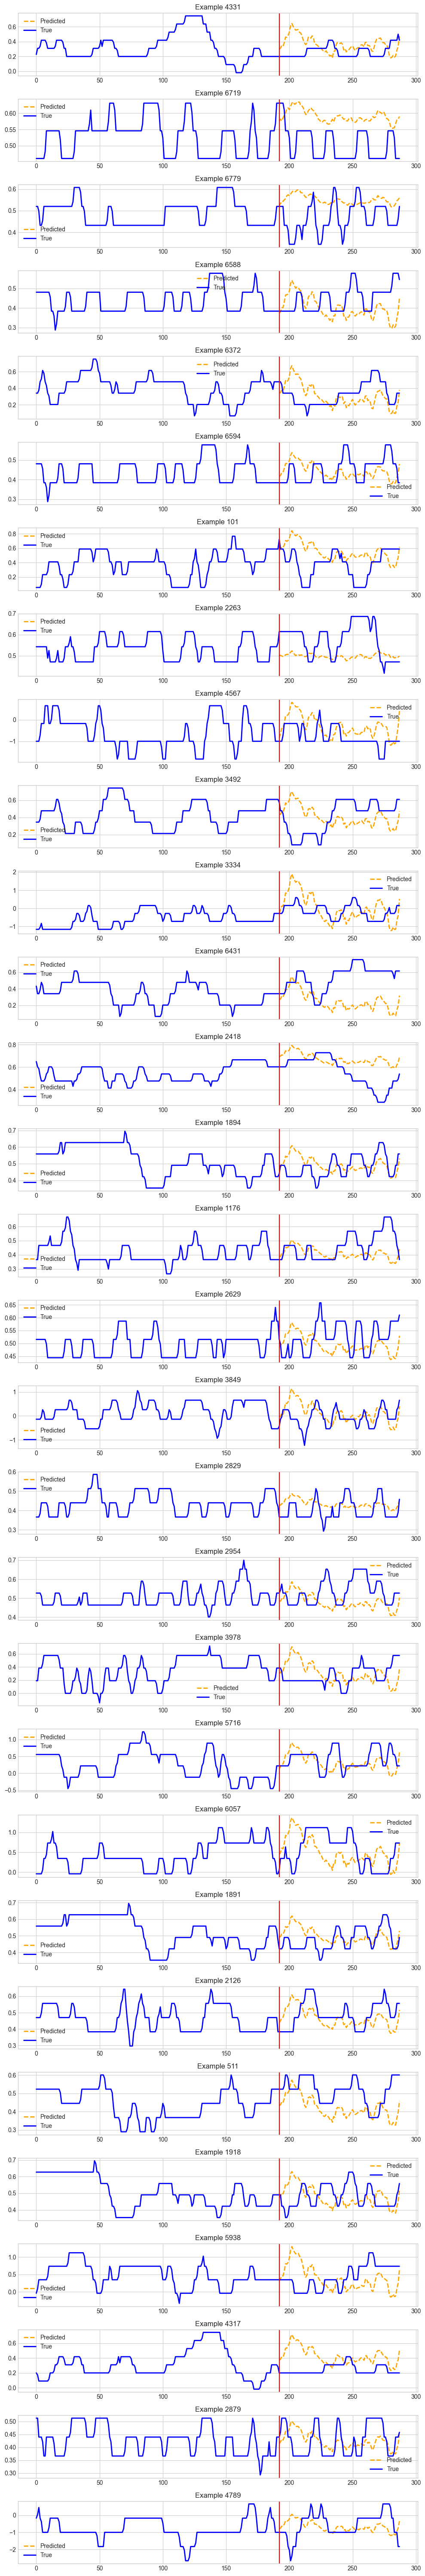

In [194]:
plot_predictions(
    model=finetune_forecast_model,
    dset=test_dataset,
    plot_prefix="test_finetune",
    channel=0,
    num_plots=30
)